In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc
import pylatexenc

# Algoritmo de Grover

## Oráculo genérico
Implementa un oráculo cuántico genérico que marca uno o más estados objetivo aplicando una fase negativa. Esta implementación es útil para probar el algoritmo de Grover sin necesidad de una lógica específica de problema.

In [ ]:
from qiskit import QuantumCircuit
from matplotlib.pyplot import show

def generic_oracle(targets: set[str]) -> QuantumCircuit:
    """Marcar estados objetivos con fase negativa

        Args:
            targets (set[str]): cadenas binarias de N qubits representando estados objetivos

        Returns:
            qc: Oráculo representado en un circuito cuántico.
        """
    n_qubits = len(next(iter(targets)))
    # Crear circuito cuántico de N qubits para el oráculo
    qc = QuantumCircuit(n_qubits, name="Oracle")

    for target in targets:
        # Usar little-endian para compatibilidad con Qiskit
        target = target[::-1]
        # Invertir qubits 0
        for i, bit in enumerate(target):
            if bit == "0":
                # Puerta Pauli-X
                qc.x(i)

        # Simular puerta (N-1)-control Z
        # 1. Puerta Hadamard
        qc.h(n_qubits - 1)

        # 2. Puerta (N - 1)-control Toffoli
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)

        # 3. Puerta Hadamard
        qc.h(n_qubits - 1)
        # Invertir a estado original
        for i, bit in enumerate(target):
            if bit == "0":
                # Puerta Pauli-X
                qc.x(i)
    return qc

qc = generic_oracle({"0101", "0100"})
qc.draw("mpl")
show()

## Oráculo XOR
Implementa un oráculo cuántico personalizado para cifrado XOR. Simula la operación `plaintext ⊕ key` y marca como solución la clave que genera el `ciphertext` esperado. Esta implementación es un ejemplo de problema real modelado para Grover.

In [ ]:
from qiskit.circuit import QuantumRegister, QuantumCircuit
from matplotlib.pyplot import show

def xor_oracle(plaintext: str, ciphertext: str, insert_barriers: bool = True)  -> QuantumCircuit:
    assert len(plaintext) == len(ciphertext), "La longitud del texto plano y del texto cifrado debe ser la misma"
    n_qubits = len(plaintext)

    # La clave es de tamaño n_qubits
    qc = QuantumCircuit(n_qubits, name="Oracle")

    # Debemos comprobar si la clave XOR con el texto plano es igual al texto cifrado (key XOR plaintext = ciphertext)

    # Primero, calculamos la clave XOR con el texto plano, lo cual se hace usando compuertas X
    for index, bit in enumerate(plaintext[::-1]): # [::-1] para cumplir con el formato little-endian de Qiskit
        if bit == "1":
            qc.x(index)

    # Aplicamos una barrera para una mejor visualización
    if insert_barriers:
        qc.barrier()

    # Ahora queremos voltear el estado si es igual al texto cifrado
    # Una operación C^n-Z volteará el estado si todos los qubits están en 1, por lo que solo tenemos que
    # voltear los bits del estado que deberían corresponder a un 0 en el texto cifrado

    for index, bit in enumerate(ciphertext[::-1]): # [::-1] para cumplir con el formato little-endian de Qiskit
        if bit == "0":
            qc.x(index)

    # Aplicamos una barrera para una mejor visualización
    if insert_barriers:
        qc.barrier()

    # Aplicamos una compuerta MCZ usando MCX
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), [n_qubits - 1])
    qc.h(n_qubits - 1)

    if insert_barriers: # Solo para una mejor visualización
        qc.barrier()

    # Revertimos las compuertas X

    for index, bit in enumerate(ciphertext[::-1]): # [::-1] para cumplir con el formato little-endian de Qiskit
        if bit == "0":
            qc.x(index)

    if insert_barriers: # Solo para una mejor visualización
        qc.barrier()

    for index, bit in enumerate(plaintext[::-1]): # [::-1] para cumplir con el formato little-endian de Qiskit
        if bit == "1":
            qc.x(index)

    return qc

qc = xor_oracle("0101", "0100")
qc.draw("mpl")
show()

## Grover
Ejecuta el algoritmo de Grover completo: crea la superposición, aplica el oráculo seleccionado (`genérico` o `XOR`), aplica el difusor y mide el resultado. Muestra el circuito generado y un histograma con los estados medidos.

GANADOR(ES):
Binario = ['01011', '00011', '00000', '01001']
Decimal = [11, 3, 0, 9]

OBJETIVO(S):
Binario = {'00000', '00011', '01011', '01001'}
Decimal = {0, 9, 11, 3}

¡Objetivo(s) encontrados con una precisión del 96.10%!


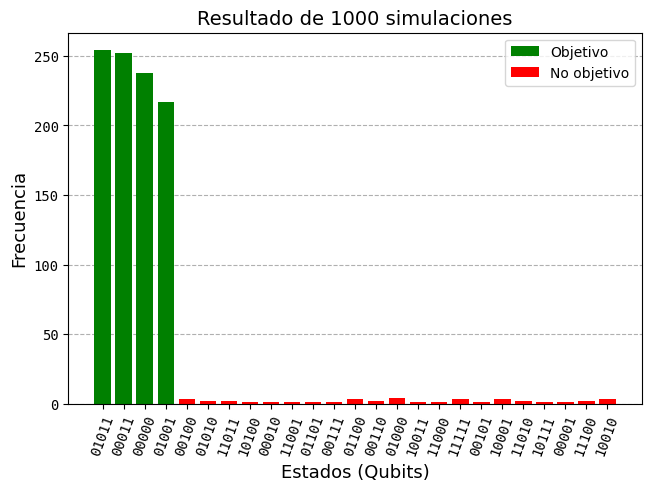

In [ ]:
from argparse import ArgumentParser, Namespace, BooleanOptionalAction
from qiskit import QuantumCircuit as qc
from qiskit import QuantumRegister as qr
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.result import Counts
from matplotlib.pyplot import show, subplots, xticks, yticks, savefig
from math import pi, sqrt
from heapq import nlargest

class GroversAlgorithm:
    def __init__(self,
                 title: str = "Grover's Algorithm",
                 n_qubits: int = 5,
                 search: set[int] = { 11, 9, 0, 3 },
                 shots: int = 1000,
                 fontsize: int = 10,
                 print: bool = False,
                 combine_states: bool = False) -> None:
        """
        Simula el algoritmo de Grover usando AerSimulator de Qiskit.

        Args:
            title (str, optional): Título de la ventana. Por defecto es "Grover's Algorithm".
            n_qubits (int, optional): Número de qubits. Por defecto es 5.
            search (set[int], optional): Conjunto de enteros no negativos a buscar usando el algoritmo de Grover. Por defecto es { 11, 9, 0, 3 }.
            shots (int, optional): Cantidad de veces que se simula el algoritmo. Por defecto es 10000.
            fontsize (int, optional): Tamaño de fuente del histograma. Por defecto es 10.
            print (bool, optional): Si se debe imprimir o no el circuito cuántico. Por defecto es False.
            combine_states (bool, optional): Si se deben combinar todos los estados que no son solución en una sola barra llamada "Others". Por defecto es False.
        """
        self.title = title
        self.n_qubits = n_qubits
        self.shots = shots
        self.fontsize = fontsize
        self.print_circuit = print
        self.combine_states = combine_states

        # Conjunto de enteros no negativos a buscar
        self.search: set[int] = set(search)

        # Conjunto de cadenas binarias de n_qubits que representan los estados objetivo (self.search en base 2)
        self._targets: set[str] = { f"{s:0{self.n_qubits}b}" for s in self.search }

        # Registro cuántico de n_qubits
        self._qubits: qr = qr(self.n_qubits, "qubit")

    def _print_circuit(self, circuit: qc, name: str) -> None:
        """Imprime el circuito cuántico.

        Args:
            circuit (qc): Circuito cuántico a imprimir.
            name (str): Nombre del circuito cuántico.
        """
        print(f"\n{name}:\n{circuit}")

    def _oracle(self, targets: set[str]) -> qc:
        return generic_oracle(targets)

    def _diffuser(self) -> qc:
        """Amplifica la amplitud del/de los estado(s) objetivo(s),
        lo que disminuye las amplitudes de los otros estados y aumenta
        la probabilidad de obtener la solución correcta.

        Returns:
            qc: Circuito cuántico que representa el difusor (operador de difusión de Grover).
        """
        # Crear circuito cuántico de n_qubits para el difusor
        diffuser = qc(self._qubits, name = "Diffuser")

        # Compuerta Hadamard
        diffuser.h(self._qubits)

        # Oráculo con estado objetivo de solo ceros
        diffuser.append(self._oracle({"0" * self.n_qubits}), list(range(self.n_qubits)))

        # Compuerta Hadamard
        diffuser.h(self._qubits)

        # Mostrar difusor, si aplica
        if self.print_circuit: self._print_circuit(diffuser, "DIFFUSER")

        return diffuser

    def _grover(self) -> qc:
        """Crea la representación en circuito cuántico del algoritmo de Grover,
        que consiste en 4 partes: (1) preparación/inicialización del estado,
        (2) oráculo, (3) difusor, y (4) medición del estado resultante.

        Los pasos 2-3 se repiten un número óptimo de veces (iteraciones de Grover)
        para maximizar la probabilidad de éxito.

        Returns:
            qc: Circuito cuántico del algoritmo de Grover.
        """
        # Crear circuito cuántico de n_qubits para Grover
        grover = qc(self._qubits, name = "Grover Circuit")

        # Inicializar los qubits con Hadamard (superposición uniforme)
        grover.h(self._qubits)

        # Aplicar barrera para separar pasos
        grover.barrier()

        # Aplicar oráculo y difusor el número óptimo de veces
        for _ in range(int((pi / 4) * sqrt((2 ** self.n_qubits) / len(self._targets)))):
            grover.append(self._oracle(self._targets), list(range(self.n_qubits)))
            grover.append(self._diffuser(), list(range(self.n_qubits)))

        # Medir todos los qubits al finalizar
        grover.measure_all()

        # Mostrar circuito si aplica
        if self.print_circuit: self._print_circuit(grover, "GROVER CIRCUIT")

        return grover

    def _outcome(self, winners: list[str], counts: Counts) -> None:
        """Imprime los estados con mayor frecuencia de medición
        y los estados objetivo, en forma binaria y decimal.
        Determina si los estados más probables coinciden con los objetivos
        e imprime el resultado.

        Args:
            winners (list[str]): Estado(s) binarios con mayor probabilidad de ser medidos.
            counts (Counts): Frecuencia de cada estado medido.
        """
        print("GANADOR(ES):")
        print(f"Binario = {winners}\nDecimal = {[ int(key, 2) for key in winners ]}\n")

        print("OBJETIVO(S):")
        print(f"Binario = {self._targets}\nDecimal = {self.search}\n")

        if not all(key in self._targets for key in winners):
            print("Objetivo(s) no encontrados...")
        else:
            winners_frequency, total = 0, 0
            for value, frequency in counts.items():
                if value in winners:
                    winners_frequency += frequency
                total += frequency
            print(f"¡Objetivo(s) encontrados con una precisión del {winners_frequency / total:.2%}!")

    def _show_histogram(self, histogram_data) -> None:
        """Imprime el resultado y muestra un histograma con los resultados de la simulación.

        Args:
            data: Frecuencia de cada estado medido.
        """
        # Estados con mayor conteo y sus frecuencias
        winners = { winner : histogram_data.get(winner) for winner in nlargest(len(self._targets), histogram_data, key = histogram_data.get) }

        # Imprimir resultado
        self._outcome(list(winners.keys()), histogram_data)

        # Valores para eje X e Y de los ganadores
        winners_x_axis = [ str(winner) for winner in [*winners] ]
        winners_y_axis = [ *winners.values() ]

        # Otros estados y sus frecuencias
        others = { state : frequency for state, frequency in histogram_data.items() if state not in winners }

        # Eje X e Y para los otros estados
        other_states_x_axis = "Others" if self.combine_states else [*others]
        other_states_y_axis = [ sum([*others.values()]) ] if self.combine_states else [ *others.values() ]

        # Crear histograma
        figure, axes = subplots(num = "Grover's Algorithm — Results", layout = "constrained")
        axes.bar(winners_x_axis, winners_y_axis, color = "green", label = "Objetivo")
        axes.bar(other_states_x_axis, other_states_y_axis, color = "red", label = "No objetivo")
        axes.legend(fontsize = self.fontsize)
        axes.grid(axis = "y", ls = "dashed")
        axes.set_axisbelow(True)

        # Títulos de gráfico y ejes
        axes.set_title(f"Resultado de {self.shots} simulaciones", fontsize = int(self.fontsize * 1.45))
        axes.set_xlabel("Estados (Qubits)", fontsize = int(self.fontsize * 1.3))
        axes.set_ylabel("Frecuencia", fontsize = int(self.fontsize * 1.3))

        # Etiquetas
        xticks(fontsize = self.fontsize, family = "monospace", rotation = 0 if self.combine_states else 70)
        yticks(fontsize = self.fontsize, family = "monospace")

        # Anotación flotante
        annotation = axes.annotate("",
                                xy = (0, 0),
                                xytext = (5, 5),
                                xycoords = "data",
                                textcoords = "offset pixels",
                                ha = "center",
                                va = "bottom",
                                family = "monospace",
                                weight = "bold",
                                fontsize = self.fontsize,
                                bbox = dict(facecolor = "white", alpha = 0.4, edgecolor = "None", pad = 0)
                                )

        savefig("results.png")

        def _hover(event) -> None:
            """Muestra la frecuencia sobre cada barra al pasar el cursor.

            Args:
                event: Evento de Matplotlib.
            """
            visibility = annotation.get_visible()
            if event.inaxes == axes:
                for bars in axes.containers:
                    for bar in bars:
                        cont, _ = bar.contains(event)
                        if cont:
                            x, y = bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height()
                            annotation.xy = (x, y)
                            annotation.set_text(y)
                            annotation.set_visible(True)
                            figure.canvas.draw_idle()
                            return
            if visibility:
                annotation.set_visible(False)
                figure.canvas.draw_idle()

        # Mostrar histograma
        id = figure.canvas.mpl_connect("motion_notify_event", _hover)
        show()

    def run(self) -> None:
        """
        Ejecuta la simulación del algoritmo de Grover.
        """
        # Simular Grover localmente
        backend = AerSimulator(method = "density_matrix")

        # Generar circuito optimizado
        transpiled_circuit = transpile(self._grover(), backend, optimization_level = 2)

        # Ejecutar simulación
        job = backend.run(transpiled_circuit, shots = self.shots)

        # Obtener resultados
        results = job.result()

        # Obtener frecuencias de estados
        data = results.get_counts()

        # Mostrar resultados
        self._show_histogram(data)

if __name__ == "__main__":
    GroversAlgorithm().run()
